# Example code for biomechzoo Ensembler
Ensembler is the plotting library associated with the biomechzoo toolbox. This notebook desmonstrates its functionality. Note: data input into these plotting functions need to be _.zoo files_ or very similarly structured as nested dictionaries.

#todo: allow comparison of multiple within file CHANNELs e.g. Hip, Knee, Ankle
#todo change conditionSource.CHANNEL to conditionSource.WITHIN and the other to BETWEEN
#todo make it clear in examples how to control color


## 1. General imports needed

In [40]:
import os
# import statements
from ensembler import Ensembler
from plot_spec import PlotSpec
# line plot and event renderers
from renderers import IndividualLinesRenderer, MeanSDRenderer, EventOverlayRenderer
from renderers import ViolinRenderer, BlandAltmanRenderer, ScatterRenderer
# combiner renderers
from renderers import CompositeRenderer
from helpers import ConditionSpec, ConditionSource

## 2. Example of setting up the structure for a within trial analysis

Here we want to compare data for the right knee angle computed using two different methods: a) Kinemat toolbox (suffix Kinemat_x) and b) plug-in gait (suffix Angles_x). Each zoo file contains both of these channels.


In [47]:
# Set up variables.
current_dir = os.getcwd()
project_root = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))
fld = os.path.join(project_root, 'data', 'sample_study', 'normalized')

spec = ConditionSpec(source = ConditionSource.CHANNEL,
                     conditions = ['Kinemat_x', 'Angles_x'],
                     channel_map = {'Kinemat_x': 'RKneeKinemat_x','Angles_x': 'RKneeAngles_x'}
                     )
channels = ['RKnee']
subj_list = [name for name in os.listdir(fld) if os.path.isdir(os.path.join(fld, name))]
rows = 1
cols = 2


### 2 a Plotting individual line plots and mean +/- standard deviation plots


In [55]:
lines_and_events = CompositeRenderer(IndividualLinesRenderer(), EventOverlayRenderer())     # within stuff
ens = Ensembler( in_folder=fld, channels=channels, n_rows=rows, n_cols=cols, subj_list=subj_list, condition_spec=spec)

ens.add_subplot(PlotSpec('Right Knee Sagittal plane', "Kinemat_x", companions=["Angles_x"], row=1, col=1, renderer=IndividualLinesRenderer(), x_label="% stance", y_label="Joint angle (deg)"))
ens.add_subplot(PlotSpec('Right Knee Sagittal plane (mean +/- SD)', "Kinemat_x", companions=["Angles_x"], row=1, col=2, renderer=MeanSDRenderer(), x_label="% stance", y_label="Joint angle (deg)"))

fig = ens.build(title="Kinemat vs Plug-in Gait")
fig.show()

### 2b. Extras
The returned fig from the ensembler allows the user all the functionality of plotly figures.
e.g. add annotations to the plot

In [57]:
fig.add_annotation(x=80, y=80, showarrow=False, text="RMSE: 0.1 deg", yshift=10, font=dict(size=18), row=1,col=2)



## 3. Example of setting up the structure for a between trial analysis

Here we want to compare kinematics between the Straight and Turn conditions


In [60]:
# Set up variables, this time we use str_match to find participants and look for events
import os
current_dir = os.getcwd()
project_root = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))
fld = os.path.join(project_root, 'data', 'sample_study', 'normalized')

spec = ConditionSpec(source = ConditionSource.FOLDER,
                     conditions = ["Straight", "Turn"])
channels = ['RightAnklePower', 'RKneeAngles_x']
str_match = [r"\bHC\d{3}[A-Z]\b"]
events = ['max','NRMSE']
rows = 1
cols = 3


### 3 a) Plotting individual line plots, events, and mean +/- standard deviation plots


In [ ]:
lines_and_events = CompositeRenderer(IndividualLinesRenderer(), EventOverlayRenderer())     # within stuff
fig = (
    Ensembler( in_folder=fld, channels=channels, n_rows=rows, n_cols=cols, str_match=str_match, condition_spec=spec, events=events)
    .add_subplot(PlotSpec('Right Ankle Power', "RightAnklePower", companions=["Angles_x"], row=1, col=1, renderer=IndividualLinesRenderer(), x_label="% stance", y_label="Joint angle (deg)")
#ens.add_subplot(PlotSpec('Right Knee Sagittal plane (mean +/- SD)', "Kinemat_x", companions=["Angles_x"], row=1, col=2, renderer=MeanSDRenderer(), x_label="% stance", y_label="Joint angle (deg)"))

#fig = ens.build(title="Kinemat vs Plug-in Gait")


In [59]:
fig = (
    Ensembler(
        in_folder=fld,  channels=channels,
        n_rows=rows,  n_cols=cols,
        str_match=str_match,
        condition_spec=spec,
        events=events)
    .add_subplot(PlotSpec(
        channel="RightAnklePower",
        condition = "Straight", companions = ["Turn"],    #todo :why do I repeat this if I set up the variables earlier
        row=1, col=1,
        renderer=ViolinRenderer(),
        events=['max'],)
    )
    .add_subplot(PlotSpec(
        channel="RightAnklePower",
        condition="Straight", companions=["Turn"],
        row=1, col=2,
        renderer=ViolinRenderer(),
        events=['NRMSE'])
    )
    .build(title="Metrics Straight vs Turn")
)
fig.show()

## Example Scatter plot with regression line and Band-Altman plot
The show_subjects operator allows users to plot the individual subject colors in the markers. Might make it useful to figure out individual trends.

In [8]:
fld = "/Users/Werk/Documents/Postdoc-McGill/areve-mcgill/data/Phase2/17-Stats"

spec = ConditionSpec(
    source     = ConditionSource.WITHIN,
    conditions = ["vicon", "areve", 'pig'],
    channel_map = {
        "vicon": "RS_abduction_vicon",
        "areve": "RS_abduction_areve",
        "pig" : "RS_abduction_pig",
    }
)
channels = ['RS_abduction']
str_match = [r"\b\d{3}[A-Z]{2}\b", r"\b\d{3}[A-Z]{3}\b"]
# subj_list = ["001CEJ"]
events = ["max"]
rows = 1
cols = 3

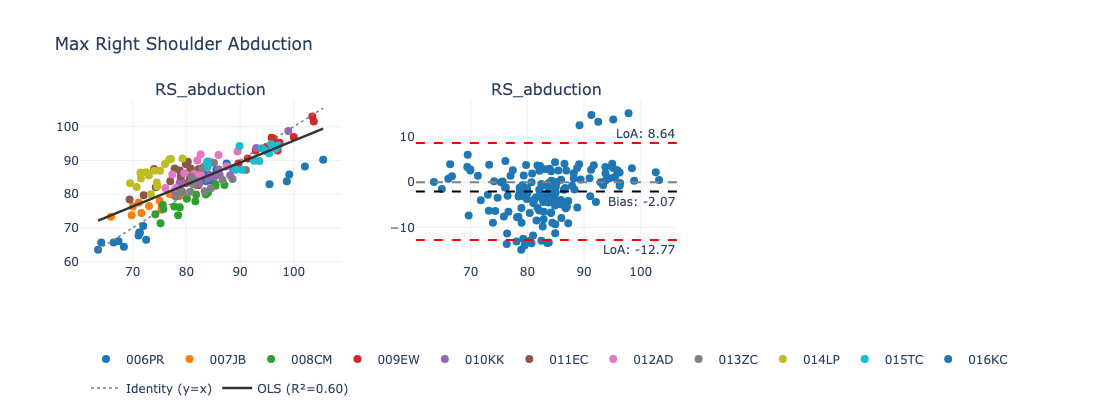

In [9]:
fig = (
    Ensembler(in_folder=fld, channels=channels, n_rows= rows, n_cols =cols, str_match=str_match, condition_spec=spec)
    .add_subplot(PlotSpec(channel='RS_abduction',
                          condition="areve", companions=["pig"],
                          row=1, col=1,
                          renderer=ScatterRenderer(regression_line= True, show_subjects = True), events=events))
    .add_subplot(PlotSpec(channel='RS_abduction',
                          condition="areve", companions=["pig"],
                          row=1, col=2, renderer=BlandAltmanRenderer(use_events= True, show_subjects=False), events=events))
    .build(title="Max Right Shoulder Abduction")
)

fig.show()

In [10]:
spec = ConditionSpec(
    source=ConditionSource.WITHIN,
    conditions=["vicon", "areve", 'pig'],
    channel_map={
        "vicon": "RS_abduction_vicon",
        "areve": "RS_abduction_areve",
        "pig": "RS_abduction_pig",
    }
)
channels = ['RS_abduction']
str_match = [r"\b\d{3}[A-Z]{2}\b", r"\b\d{3}[A-Z]{3}\b"]
# subj_list = ["001CEJ"]
events = ["rmse_vicon"]
rows = 1
cols = 3


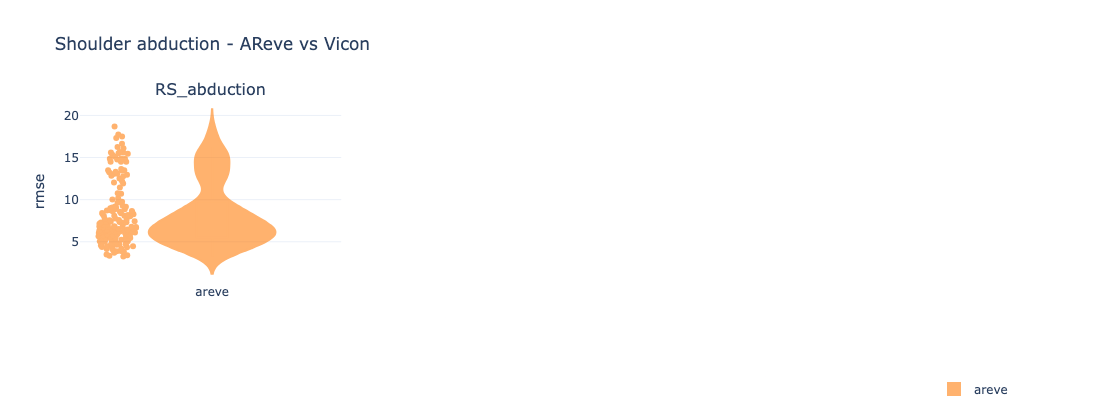

In [11]:
fig = (
    Ensembler(in_folder=fld, channels=channels, n_rows = rows,  n_cols =cols,
              str_match=str_match, condition_spec=spec)
    .add_subplot(PlotSpec(channel='RS_abduction',  condition="areve",
                          row=1, col=1, y_label="rmse",
                          renderer=ViolinRenderer(), events=events))
    .build(title="Shoulder abduction - AReve vs Vicon", )
)
fig.show()